In [31]:
import matplotlib.pyplot as plt
import numpy as np
import json

In [38]:
data_tokenskip = []
compression_ratio = 0.7
file_path = f"math-500-test/{compression_ratio}/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip.append(json.loads(line))

In [33]:
data_original = []

file_path = f"predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_original.append(json.loads(line))

In [34]:
data_optimal = []
optimal_compression_ratio = 1.0
file_path = f"clustered/math-500-test/{optimal_compression_ratio}/samples/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_optimal.append(json.loads(line))

print(data_optimal[0])  # first JSON object


{'dataset': 'math-test', 'id': 'math-test-test-0-0', 'level': 2, 'type': 'Precalculus', 'messages': [{'role': 'user', 'content': 'Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$'}, {'role': 'assistant', 'content': ''}], 'answer': ['(3,\\frac{\\pi}{2})'], 'reference': ['We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0.8 cm);\n\ndraw((-0.5,0)--(3.5,0));\ndraw((0,-0.5)--(0,3.5));\ndraw(arc((0,0),3,0,90),red,Arrow(6));\n\ndot((0,3), red);\nlabel("$(0,3)$", (0,3), W);\ndot((3,0), red);\n[/asy]\n\nTherefore, the polar coordinates are $\\boxed{\\left( 3, \\frac{\\pi}{2} \\right)}.$'], 'prompt': '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nPlease reason step by step, and put your final answer with

In [9]:
data3 = []

for q1,q2 in zip(data1,data2):
    new_dict = {}
    if(q1["accuracy"]==True and q2["accuracy"]==False):
        new_dict["id"] = q1["id"]
        new_dict["type"] = q1["type"]
        new_dict["question"] = q1["messages"][0]["content"]
        new_dict["answer"] = q1["answer"]
        new_dict["model_output1"] = q1["model_output"]
        new_dict["prediction1"] = q1["prediction"]
        new_dict["cot_length1"] = q1["cot_length"]
        new_dict["model_output2"] = q2["model_output"]
        new_dict["prediction2"] = q2["prediction"]
        new_dict["cot_length2"] = q2["cot_length"]
        data3.append(new_dict)

print(data3[0])

{'id': 'math-test-test-14-0', 'type': 'Precalculus', 'question': 'Suppose $\\sin D = 0.7$ in the diagram below. What is $DE$? [asy]\npair D,E,F;\nF = (0,0);\nD = (sqrt(51),7);\nE = (0,7);\ndraw(D--E--F--D);\ndraw(rightanglemark(D,E,F,15));\nlabel("$D$",D,NE);\nlabel("$E$",E,NW);\nlabel("$F$",F,SW);\nlabel("$7$",(E+F)/2,W);\n[/asy]', 'answer': ['\\sqrt{51}'], 'model_output1': 'determine length \\( DE  use Pythagorean theorem right triangle \\( DEF  \\(\\angle E = 90^\\circ\\). know lengths two sides triangle: - \\( DF = 7 \\) (given) - \\( \\sin D = 0.7 \\). sine function defined as ratio of length opposite side to hypotenuse in right triangle. \\[ \\sin D = \\frac{DF}{EF} \\] Substituting known values: \\[ 0.7 = \\frac{7}{EF} \\] solve for \\( EF \\): \\[ EF = \\frac{7}{0.7} = 10 \\] \\( EF = 10 \\), use Pythagorean theorem find \\( DE \\). Pythagorean theorem states: \\[ DF^2 + DE^2 = EF^2 \\] Substituting known values: \\[ 7^2 + DE^2 = 10^2 \\] Simplify equation: \\[ 49 + DE^2 = 100 

In [10]:
print(len(data3))

25


In [13]:
with open("wrong_answers.json", "w", encoding="utf-8") as f:
    json.dump(
        data3,
        f,
        ensure_ascii=False,  # keep UTF-8 characters
        indent=2         # word-wrap via indentation
        
    )


In [6]:
print(type(data[0]['cot_length']))

<class 'int'>


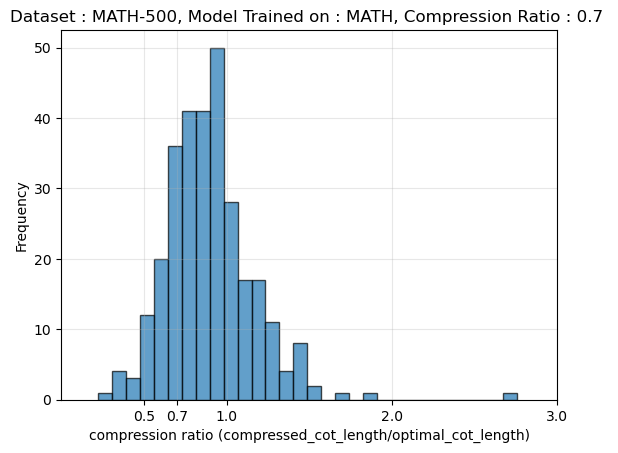

In [5]:
import matplotlib.pyplot as plt

cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
    if d1.get('accuracy')
]

plt.hist(cot_ratio_tokenskip, bins=30, edgecolor = 'black',alpha = 0.7)

xticks = [0.5,0.7,1.0,2.0,3.0]
plt.xticks(xticks)
plt.xlim(0,3.0)
plt.xlabel("compression ratio (compressed_cot_length/optimal_cot_length)")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Model Trained on : MATH, Compression Ratio : {compression_ratio} ")
plt.grid(True, alpha=0.3)
plt.show()

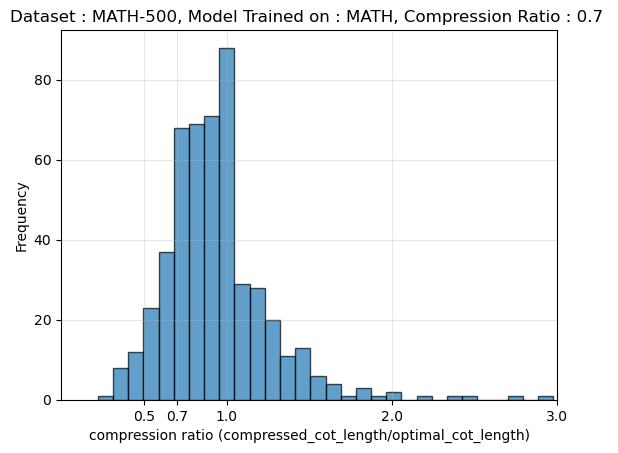

In [6]:
import matplotlib.pyplot as plt

cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
]

plt.hist(cot_ratio_tokenskip, bins=30, edgecolor = 'black',alpha = 0.7)

xticks = [0.5,0.7,1.0,2.0,3.0]
plt.xticks(xticks)
plt.xlim(0,3.0)
plt.xlabel("compression ratio (compressed_cot_length/optimal_cot_length)")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Model Trained on : MATH, Compression Ratio : {compression_ratio} ")
plt.grid(True, alpha=0.3)
plt.show()

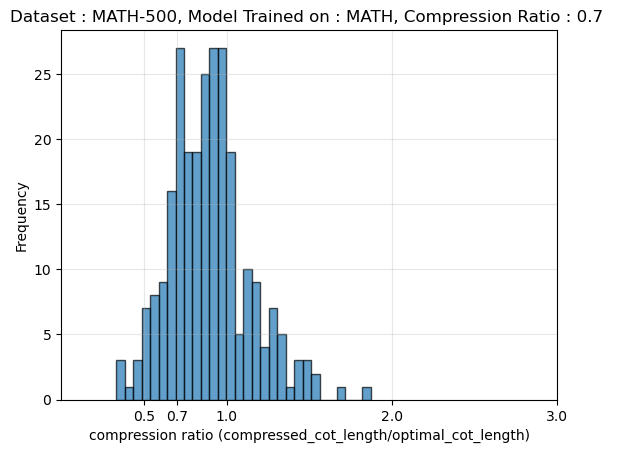

Avg cot ratio : 0.8952843732232951
std dev cot ratio : 0.24168221486943414


In [5]:
import matplotlib.pyplot as plt
import statistics

cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
    if d1.get('accuracy') and d2.get('accuracy')
]

plt.hist(cot_ratio_tokenskip, bins=30, edgecolor = 'black',alpha = 0.7)

xticks = [0.5,0.7,1.0,2.0,3.0]
plt.xticks(xticks)
plt.xlim(0,3.0)
plt.xlabel("compression ratio (compressed_cot_length/optimal_cot_length)")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Model Trained on : MATH, Compression Ratio : {compression_ratio} ")
plt.grid(True, alpha=0.3)
plt.show()


avg_cot_ratio = np.mean(cot_ratio_tokenskip)
std_dev_ratio = statistics.pstdev(cot_ratio_tokenskip)

print(f"Avg cot ratio : {avg_cot_ratio}")
print(f"std dev cot ratio : {std_dev_ratio}")


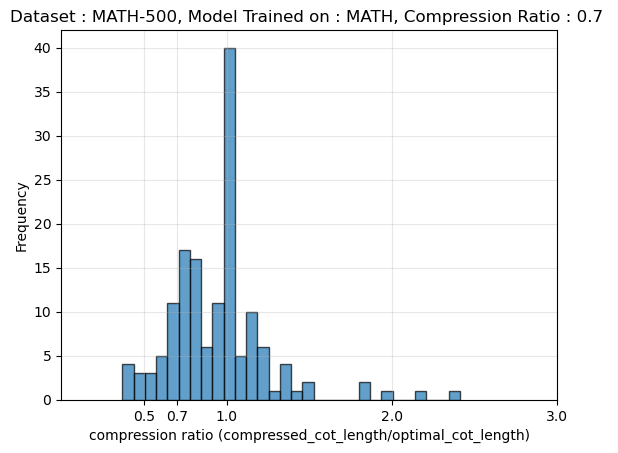

Avg cot ratio : 0.9475514485904479
std dev cot ratio : 0.3042821866196786


In [39]:
import matplotlib.pyplot as plt
import statistics

cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
    if not d1.get('accuracy') and not d2.get('accuracy')
]

plt.hist(cot_ratio_tokenskip, bins=30, edgecolor = 'black',alpha = 0.7)

xticks = [0.5,0.7,1.0,2.0,3.0]
plt.xticks(xticks)
plt.xlim(0,3.0)
plt.xlabel("compression ratio (compressed_cot_length/optimal_cot_length)")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Model Trained on : MATH, Compression Ratio : {compression_ratio} ")
plt.grid(True, alpha=0.3)
plt.show()


avg_cot_ratio = np.mean(cot_ratio_tokenskip)
std_dev_ratio = statistics.pstdev(cot_ratio_tokenskip)

print(f"Avg cot ratio : {avg_cot_ratio}")
print(f"std dev cot ratio : {std_dev_ratio}")

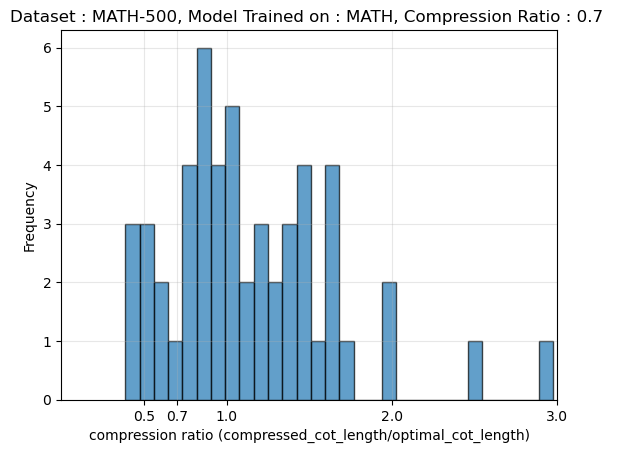

Avg cot ratio : 1.1545042540434478
std dev cot ratio : 0.5037892999242889


In [35]:
import matplotlib.pyplot as plt
import statistics

cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
    if not d1.get('accuracy') and d2.get('accuracy')
]

plt.hist(cot_ratio_tokenskip, bins=30, edgecolor = 'black',alpha = 0.7)

xticks = [0.5,0.7,1.0,2.0,3.0]
plt.xticks(xticks)
plt.xlim(0,3.0)
plt.xlabel("compression ratio (compressed_cot_length/optimal_cot_length)")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Model Trained on : MATH, Compression Ratio : {compression_ratio} ")
plt.grid(True, alpha=0.3)
plt.show()


avg_cot_ratio = np.mean(cot_ratio_tokenskip)
std_dev_ratio = statistics.pstdev(cot_ratio_tokenskip)

print(f"Avg cot ratio : {avg_cot_ratio}")
print(f"std dev cot ratio : {std_dev_ratio}")

In [9]:
import numpy as np

target_d1_lengths = []

# Assuming data_tokenskip and data_original have been loaded
for d1, d2 in zip(data_tokenskip, data_original):
    # Check if both predictions are incorrect (accuracy is False)
    # Using .get() in case the key is missing, defaulting to False
    if not d1.get('accuracy', False) and not d2.get('accuracy', False):
        if d2['cot_length'] > 0:
            ratio = d1['cot_length'] / d2['cot_length']
            
            # Using absolute difference is safer for float comparisons
            if abs(ratio - 1.0) < 0.01:
                target_d1_lengths.append(d1['cot_length'])

if target_d1_lengths:
    average_length = np.mean(target_d1_lengths)
    print(f"Number of such examples: {len(target_d1_lengths)}")
    print(f"Average d1 CoT length: {average_length:.2f}")
    print(f"Min d1 CoT length: {np.min(target_d1_lengths)}")
    print(f"Max d1 CoT length: {np.max(target_d1_lengths)}")
else:
    print("No examples found matching the criteria.")


Number of such examples: 37
Average d1 CoT length: 986.49
Min d1 CoT length: 461
Max d1 CoT length: 1024


In [ ]:
cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
    if d1.get('accuracy') and d2.get('accuracy')
]

items_in_range_09_11 = []

for d1, d2 in zip(data_tokenskip, data_original):
    if d1.get('accuracy') and d2.get('accuracy'):
        d1_len = d1['cot_length']
        d2_len = d2['cot_length']
        
        ratio = d1_len / d2_len
        if 0.9 <= ratio <= 1.1:
            items_in_range_09_11.append((d1_len, d2_len, d1, d2))

if items_in_range_09_11:
    cot_lengths = [x[0] for x in items_in_range_09_11]
    count = len(cot_lengths)
    avg_cot = np.mean(cot_lengths/original_lengths)
    avg_cot_ratio = np.mean(cot)
    std_cot = np.std(cot_lengths)
    min_cot = np.min(cot_lengths)
    max_cot = np.max(cot_lengths)

    print(f"Stats for cot_ratio in [0.9, 1.1]:")
    print(f"Count: {count}")
    print(f"Average: {avg_cot}")
    print(f"Std Dev: {std_cot}")
    print(f"Average cot ratio: {avg_cot_ratio}")
    print(f"Min: {min_cot}")
    print(f"Max: {max_cot}")

else:
    print("No samples in range [0.9, 1.1]")

Stats for cot_ratio in [0.9, 1.1]:
Count: 76
Average: 424.5263157894737
Std Dev: 158.35756290285556
Min: 199
Max: 950


In [46]:
items_in_range_09_11.sort(key=lambda x: x[0])
smallest_5 = items_in_range_09_11[:5]

print("\n--- 5 Smallest COT Lengths (TokenSkip) in Range [0.9, 1.1] ---")
for i, (length, d1, d2) in enumerate(smallest_5, 1):
        print(f"\nItem {i}:")
        print(f"Tokenskip COT Length: {length}")
        print(f"Base COT Length: {d2['cot_length']}")
        print(f"Ratio: {length / d2['cot_length']:.4f}")
        
        if 'messages' in d1:
            print(f"Question: {d1['messages'][0]['content']}")
        
        print(f"TokenSkip Answer: {d1.get('model_output', 'N/A')}")
        print(f"Optimal Answer: {d2.get('model_output', 'N/A')}")
        print("-" * 20)



--- 5 Smallest COT Lengths (TokenSkip) in Range [0.9, 1.1] ---

Item 1:
Tokenskip COT Length: 199
Base COT Length: 217
Ratio: 0.9171
Question: If $2^8=4^x$, what is the value of $x$?
TokenSkip Answer: solve equation \(2^8 = 4^x\), follow steps: 1. **Express both sides same base:** \(4\) written as power of \(2\). \(4 = 2^2\). rewrite \(4^x\) using this information: \[4^x = (2^2)^x.\] Using property of exponents \((a^m)^n = a^{mn}\), simplify right-hand side: \[(2^2)^x = 2^{2x}.\] equation becomes: \[2^8 = 2^{2x}. 2. **Set exponents equal to each other:** bases same set exponents equal: \[8 = 2x. 3. **Solve for \(x\):** Divide both sides by 2: \[x = \frac{8}{2} = 4.\] value of \(x\) is \(\boxed{4}\).

The final answer is: $\boxed{4}$
Optimal Answer: To solve the equation \(2^8 = 4^x\), we need to express both sides of the equation with the same base. Notice that \(4\) can be written as a power of \(2\):

\[4 = 2^2.\]

Therefore, we can rewrite \(4^x\) as:

\[4^x = (2^2)^x.\]

Using the

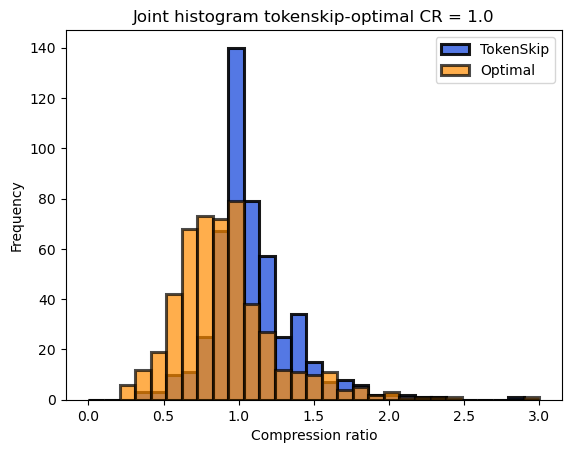

In [39]:
import matplotlib.pyplot as plt


cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
]

cot_ratio_optimal = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_optimal, data_original)
]

bins = np.linspace(0, 3.0, 30)
#bins = 30

plt.hist(cot_ratio_tokenskip, bins=bins,
         color='royalblue', edgecolor='black',
         linewidth=2.2,
         alpha=0.9, label='TokenSkip')

plt.hist(cot_ratio_optimal, bins=bins,
linewidth=2.2,
         color='darkorange', edgecolor='black',
         alpha=0.7, label='Optimal')

plt.xlabel("Compression ratio")
plt.ylabel("Frequency")
plt.title(f"Joint histogram tokenskip-optimal CR = {compression_ratio}")
plt.legend()
plt.show()









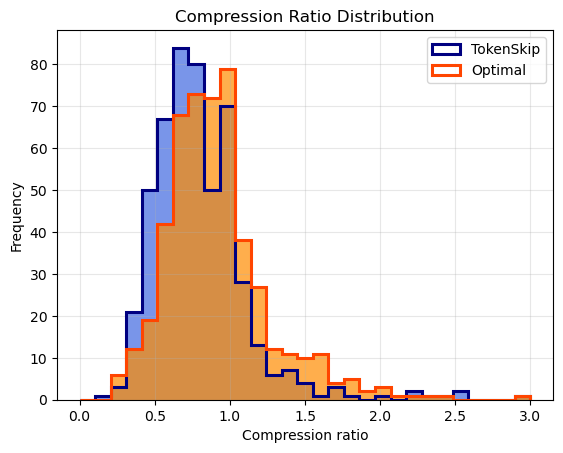

In [22]:
bins = np.linspace(0, 3.0, 30)

# Filled histograms
plt.hist(cot_ratio_tokenskip, bins=bins,
         color='royalblue', alpha=0.7)

plt.hist(cot_ratio_optimal, bins=bins,
         color='darkorange', alpha=0.7)

# Sharp outlines (contours)
plt.hist(cot_ratio_tokenskip, bins=bins,
         histtype='step',
         linewidth=2.2,
         color='navy',
         label='TokenSkip')

plt.hist(cot_ratio_optimal, bins=bins,
         histtype='step',
         linewidth=2.2,
         color='orangered',
         label='Optimal')

plt.xlabel("Compression ratio")
plt.ylabel("Frequency")
plt.title("Compression Ratio Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
plt.hist(cot_ratio, bins=30, edgecolor = 'black',alpha = 0.7)

xticks = [0.5,0.7,1.0,2.0,3.0]
plt.xticks(xticks)
plt.xlim(0,3.0)
plt.xlabel("compression ratio (compressed_cot_length/optimal_cot_length)")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Model Trained on : MATH, Compression Ratio : {compression_ratio} wrt Optimal")
plt.grid(True, alpha=0.3)
plt.show()

#plt.figure(figsize=(10, 6))

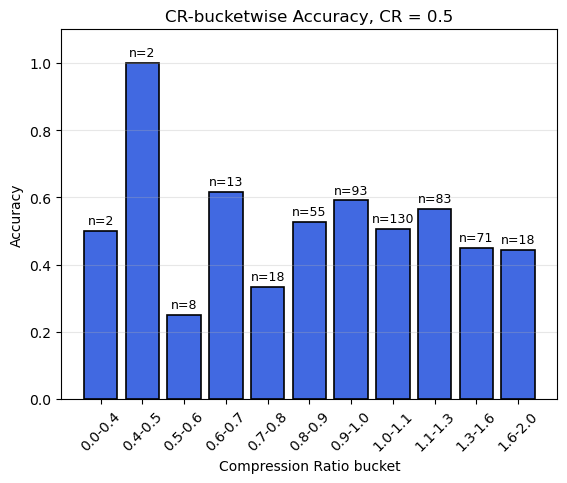

In [26]:
import numpy as np
import matplotlib.pyplot as plt


cot_ratio_tokenskip = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
]

is_correct = [d1['accuracy'] for d1 in data_tokenskip]

# Buckets
bins = [0.0,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3, 1.6, 2.0]

cr_values = np.array(cr_values)
is_correct = np.array(is_correct)

bucket_acc = []
bucket_counts = []
labels = []

for i in range(len(bins)-1):
    low, high = bins[i], bins[i+1]
    
    mask = (cr_values >= low) & (cr_values < high)
    count = np.sum(mask)
    
    if count == 0:
        acc = 0
    else:
        acc = np.mean(is_correct[mask])
    
    bucket_acc.append(acc)
    bucket_counts.append(count)
    labels.append(f"{low}-{high}")

x = np.arange(len(bucket_acc))

bars = plt.bar(x, bucket_acc,
               color='royalblue',
               edgecolor='black',
               linewidth=1.2)

plt.xticks(x, labels, rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Compression Ratio bucket")
plt.title(f"CR-bucketwise Accuracy, CR = {compression_ratio}")
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)

# Add counts above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.02,
             f"n={bucket_counts[i]}",
             ha='center',
             fontsize=9)

plt.ylim(0, 1.1)


plt.show()

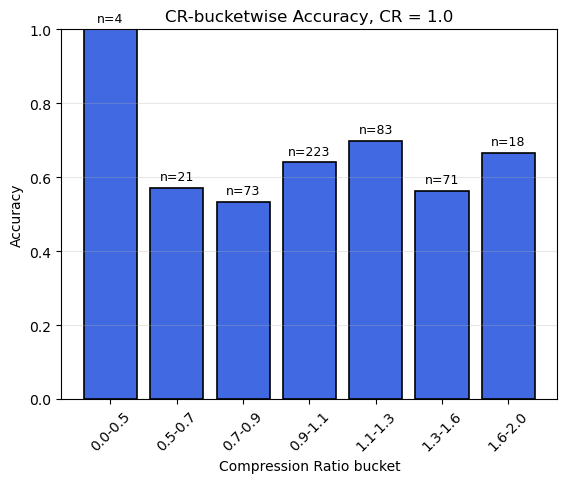

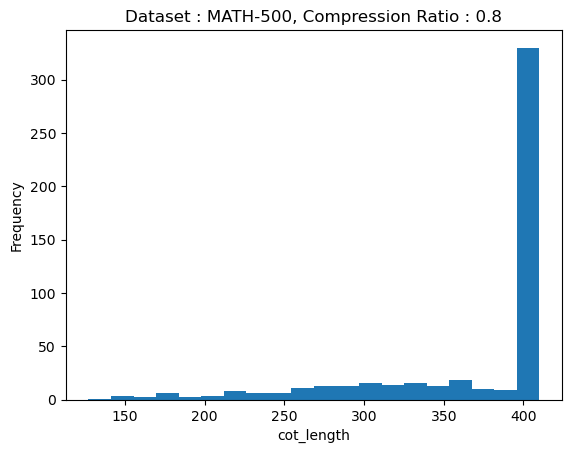

In [22]:
import matplotlib.pyplot as plt


cot_lengths = [d['cot_length'] for d in data]

plt.hist(cot_lengths, bins=20)
plt.xlabel("cot_length")
plt.ylabel("Frequency")
plt.title(f"Dataset : MATH-500, Compression Ratio : {compression_ratio}")
plt.show()


In [16]:
import statistics
import json
import numpy as np

data = []
compression_ratio = 1.0
file_path = f"clustered/math-500-test/optimal-with-compression-ratios/{compression_ratio}/samples/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

values = [d['cot_length'] for d in data]
avg = sum(values) / len(values)
max_val = np.max(values)
std = statistics.stdev(values)     # sample standard deviation
std_pop = statistics.pstdev(values)  # population standard deviation

print("Sample STD:", std)
print("Population STD:", std_pop)
print("Average : ", avg)
print("Max tokens :", max_val)


Sample STD: 269.05637871243954
Population STD: 268.78718767084115
Average :  604.912
Max tokens : 1024


In [6]:
import statistics
import json
import numpy as np

data_tokenskip = []
compression_ratio = 1.0
file_path = f"gsm8k-test/{compression_ratio}/samples/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip.append(json.loads(line))

data_original = []
file_path = f"gsm8k_predictions_org.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_original.append(json.loads(line))

tokenskip_cot_ratio = [
    d1['cot_length'] / d2['cot_length']
    for d1, d2 in zip(data_tokenskip, data_original)
]

values = [d['cot_length'] for d in data_tokenskip]
avg = sum(values) / len(values)
values_original = [d['cot_length'] for d in data_original]
avg_compression = sum(tokenskip_cot_ratio)/len(tokenskip_cot_ratio)
max_val = np.max(values)
std = statistics.stdev(values)     # sample standard deviation
std_pop = statistics.pstdev(values)  # population standard deviation
std_avg_comp = statistics.pstdev(tokenskip_cot_ratio)

print("Sample STD:", std)
print("Population STD:", std_pop)
print("Average : ",avg)
print("Max tokens : " , max_val)
print("Avg compression ratio : ", avg_compression)
print("STD CR :", std_avg_comp)


Sample STD: 89.05363562356416
Population STD: 89.01987121073968
Average :  327.40940106141016
Max tokens :  512
Avg compression ratio :  1.0515888112309386
STD CR : 0.18827389120101665


Final bins after merging (<20 items merged to next):
Idx | Range (lo, hi)               | Count | Accuracy (if >= 20)
  0 | [0.321619, 0.546619) |    21 | 0.5238
  1 | [0.546619, 0.671619) |    24 | 0.6667
  2 | [0.671619, 0.721619) |    25 | 0.6800
  3 | [0.721619, 0.771619) |    30 | 0.6667
  4 | [0.771619, 0.796619) |    20 | 0.6500
  5 | [0.796619, 0.821619) |    25 | 0.6800
  6 | [0.821619, 0.846619) |    20 | 0.7500
  7 | [0.846619, 0.871619) |    24 | 0.6667
  8 | [0.871619, 0.921619) |    36 | 0.6667
  9 | [0.921619, 0.946619) |    21 | 0.7143
 10 | [0.946619, 0.971619) |    27 | 0.7037
 11 | [0.971619, 0.996619) |    23 | 0.6957
 12 | [0.996619, 1.021619) |    38 | 0.3421
 13 | [1.021619, 1.046619) |    20 | 0.8500
 14 | [1.046619, 1.096619) |    25 | 0.6000
 15 | [1.096619, 1.146619) |    27 | 0.6667
 16 | [1.146619, 1.246619) |    26 | 0.6154
 17 | [1.246619, 1.346619) |    23 | 0.6957
 18 | [1.346619, 1.521619) |    20 | 0.4500
 19 | [1.521619, 3.546619) |    25 | 0.2800


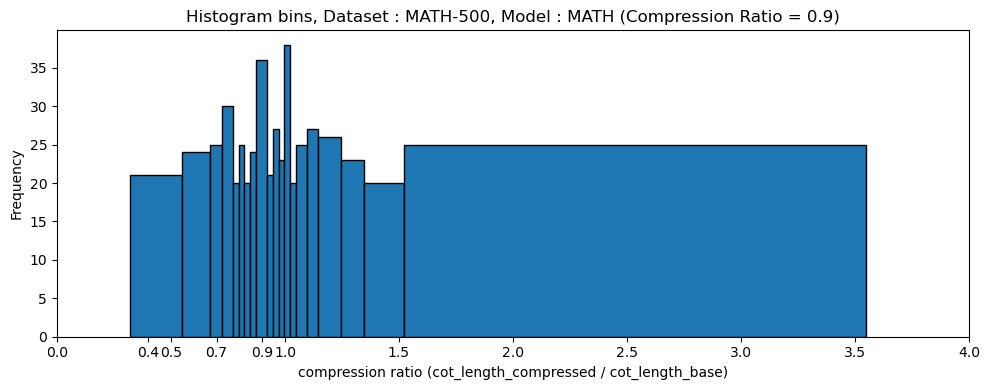

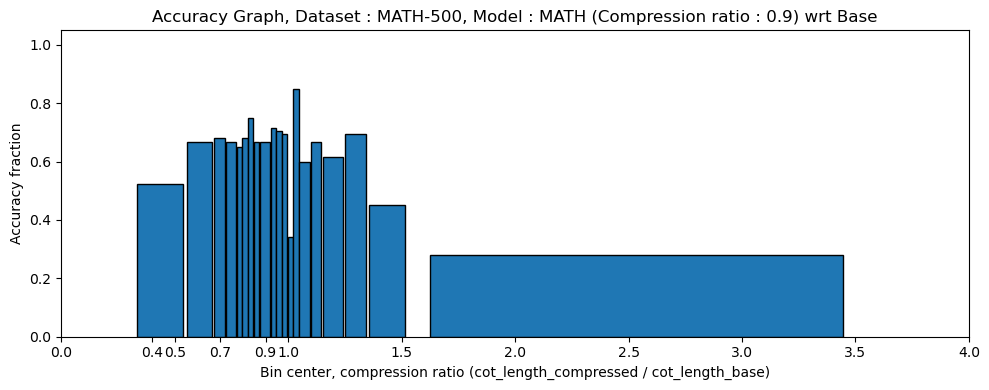

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Prepare cot_ratio and accuracies (assumes data1,data2 defined) ---
cot_ratio = np.array([d1['cot_length'] / d2['cot_length'] for d1, d2 in zip(data_tokenskip, data_original)], dtype=float)
accuracies = np.array([1 if d1.get('accuracy') else 0 for d1 in data_tokenskip], dtype=int)

if cot_ratio.size == 0:
    raise ValueError("Empty cot_ratio (data1/data2 may be empty).")

# --- fixed bin width ---
bin_width = 0.5 / 20.0  # 0.025

left_edge = float(cot_ratio.min())
right_edge = float(cot_ratio.max())
if right_edge == left_edge:
    right_edge = left_edge + bin_width

eps = 1e-12
bin_edges = np.arange(left_edge, right_edge + bin_width + eps, bin_width)
if len(bin_edges) < 2:
    bin_edges = np.array([left_edge, right_edge + bin_width])

# initial assignment to bins
num_bins = len(bin_edges) - 1
bin_idx = np.digitize(cot_ratio, bin_edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, num_bins - 1)

# build initial bins list: [lo, hi, count, acc_sum]
bins = []
for i in range(num_bins):
    lo = bin_edges[i]
    hi = bin_edges[i+1]
    mask = (bin_idx == i)
    cnt = int(mask.sum())
    acc_sum = int(accuracies[mask].sum()) if cnt > 0 else 0
    bins.append([lo, hi, cnt, acc_sum])

# --- merge rule: if a bin has < min_count, merge with next (if last, merge with prev) ---
min_count = 20

# If there are no data points at all, bins may all be zero. Handle that:
if sum(b[2] for b in bins) == 0:
    raise ValueError("No items in any bin; check cot_ratio computation.")

i = 0
while i < len(bins):
    if bins[i][2] < min_count:
        # if there's a next bin, merge with next
        if i < len(bins) - 1:
            # merge i into i+1 (i becomes merged)
            lo = min(bins[i][0], bins[i+1][0])
            hi = max(bins[i][1], bins[i+1][1])
            cnt = bins[i][2] + bins[i+1][2]
            acc_sum = bins[i][3] + bins[i+1][3]
            bins[i] = [lo, hi, cnt, acc_sum]
            del bins[i+1]
            # after merging, re-check bin i (do not increment i)
            continue
        else:
            # last bin and too small -> merge with previous
            if i == 0:
                # single bin and less than min_count: nothing to merge; break
                break
            # merge last into previous
            lo = min(bins[i-1][0], bins[i][0])
            hi = max(bins[i-1][1], bins[i][1])
            cnt = bins[i-1][2] + bins[i][2]
            acc_sum = bins[i-1][3] + bins[i][3]
            bins[i-1] = [lo, hi, cnt, acc_sum]
            del bins[i]
            # move index back one to re-check the merged bin
            i = max(i-1, 0)
            continue
    # bin has >= min_count, move to next
    i += 1

# After merging loop, bins is the final list.
final_bins = [(b[0], b[1], b[2], b[3]) for b in bins]

# Compute accuracy fraction for bins with >= min_count
bin_ranges = [(lo, hi) for lo, hi, _, _ in final_bins]
counts = [cnt for _, _, cnt, _ in final_bins]
acc_fracs = []
for lo, hi, cnt, acc_sum in final_bins:
    if cnt >= min_count and cnt > 0:
        acc_fracs.append(acc_sum / cnt)
    else:
        acc_fracs.append(np.nan)

# Print table
print("Final bins after merging (<20 items merged to next):")
print("Idx | Range (lo, hi)               | Count | Accuracy (if >= {})".format(min_count))
for idx, ((lo, hi), cnt, acc) in enumerate(zip(bin_ranges, counts, acc_fracs)):
    acc_str = f"{acc:.4f}" if not np.isnan(acc) else "N/A"
    print(f"{idx:3d} | [{lo:.6f}, {hi:.6f}) | {cnt:5d} | {acc_str}")

# Build plot edges for histogram
plot_edges = [final_bins[0][0]]
for lo, hi, _, _ in final_bins:
    plot_edges.append(hi)
plot_edges = np.array(plot_edges)

# Histogram plot
plt.figure(figsize=(10,4))
plt.hist(cot_ratio, bins=plot_edges, edgecolor='black')
xticks = list(plt.xticks()[0])   # current ticks
xticks += [0.4, 0.5, 0.7, 0.9]   # add your custom ticks
plt.xticks(sorted(set(xticks)))  # remove duplicates & sort
plt.xlabel("compression ratio (cot_length_compressed / cot_length_base)")
plt.ylabel("Frequency")
plt.title(f"Histogram bins, Dataset : MATH-500, Model : MATH (Compression Ratio = {compression_ratio})")
plt.tight_layout()
plt.show()

# Accuracy per-bin plot (bins with >= min_count)
valid_idxs = [i for i, c in enumerate(counts) if c >= min_count]
if valid_idxs:
    centers = [(bin_ranges[i][0] + bin_ranges[i][1]) / 2 for i in valid_idxs]
    widths = [bin_ranges[i][1] - bin_ranges[i][0] for i in valid_idxs]
    vals = [acc_fracs[i] for i in valid_idxs]
    plt.figure(figsize=(10,4))
    plt.bar(centers, vals, width=np.array(widths) * 0.9, edgecolor='black')
    #for xc, val, i in zip(centers, vals, valid_idxs):
        #plt.text(xc, val + 0.01, f"n={counts[i]}", ha='center', va='bottom', fontsize=8)
    plt.xlabel("Bin center, compression ratio (cot_length_compressed / cot_length_base)")
    plt.ylabel("Accuracy fraction")
    xticks = list(plt.xticks()[0])   # current ticks
    xticks += [0.4, 0.5, 0.7, 0.9]   # add your custom ticks
    plt.xticks(sorted(set(xticks)))  # remove duplicates & sort
    plt.title(f"Accuracy Graph, Dataset : MATH-500, Model : MATH (Compression ratio : {compression_ratio}) wrt Base")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
else:
    print(f"No bin has >= {min_count} items; accuracy plot not shown.")


In [25]:
import statistics
import json
import numpy as np

data1 = []
compression_ratio = 1.0
file_path = f"clustered/math-500-test/optimal-with-compression-ratios/{compression_ratio}/samples/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data1.append(json.loads(line))

data2 = []
file_path = f"predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data2.append(json.loads(line))

values = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data1, data2)]
avg = sum(values) / len(values)
max_val = np.max(values)
std = statistics.stdev(values)     # sample standard deviation
std_pop = statistics.pstdev(values)  # population standard deviation

print("Sample STD:", std)
print("Population STD:", std_pop)
print("Average : ", avg)
print("Max tokens :", max_val)

Sample STD: 0.3366528801434894
Population STD: 0.3363160587683687
Average :  1.0883791267293284
Max tokens : 3.190031152647975


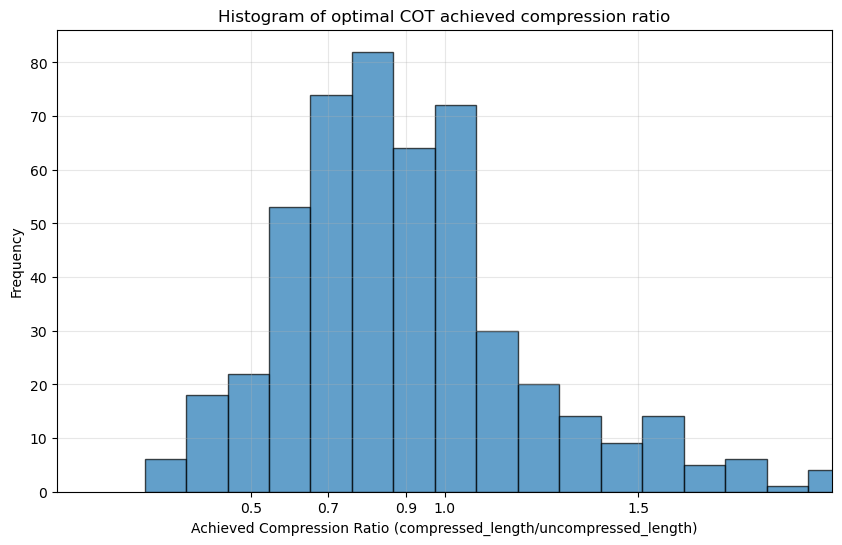

In [12]:
import matplotlib.pyplot as plt

# Calculate ratios
values = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data1, data2)]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(values, bins=30, edgecolor='black', alpha=0.7)
xticks = [0.5,0.7,0.9,1.0,1.5]
plt.xticks(xticks)
plt.xlim(0,2.0)
plt.xlabel('Achieved Compression Ratio (compressed_length/uncompressed_length)')
plt.ylabel('Frequency')
plt.title(f'Histogram of optimal COT achieved compression ratio')
plt.grid(True, alpha=0.3)
plt.show()

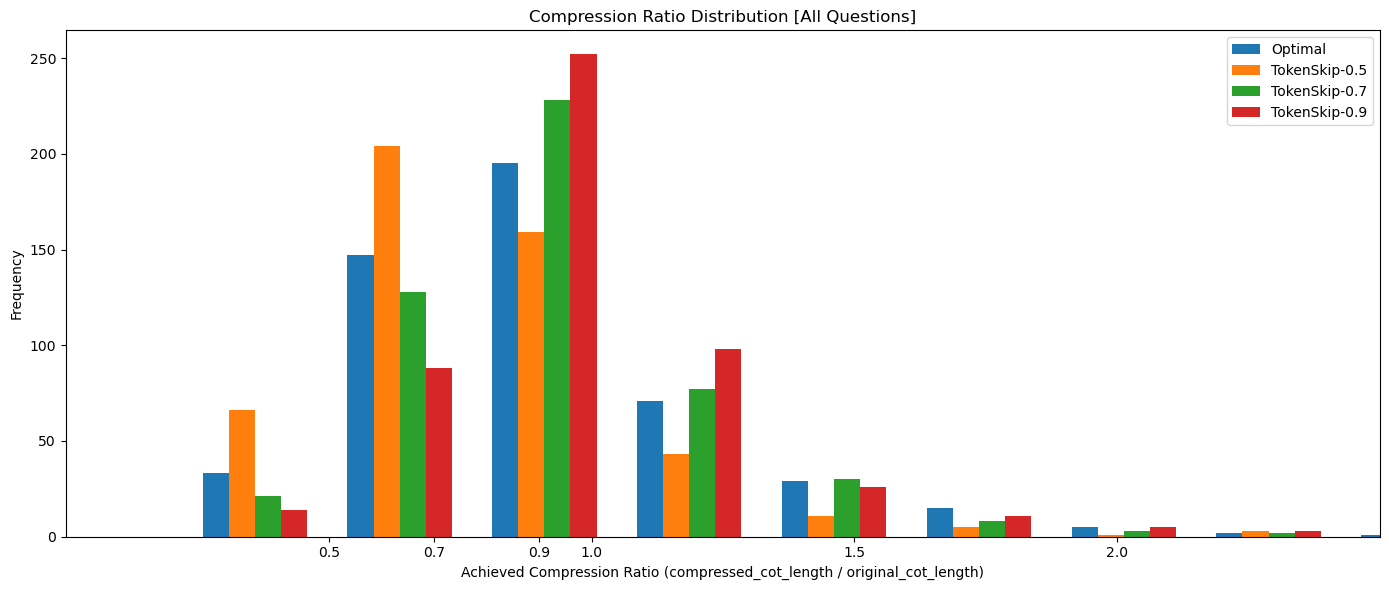

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json

data_original = []
file_path = f"predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_original.append(json.loads(line))

data_tokenskip_05 = []
file_path = f"math-500-test/0.5/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip_05.append(json.loads(line))

tokenskip_05_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_tokenskip_05, data_original)]


data_tokenskip_07 = []
file_path = f"math-500-test/0.7/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip_07.append(json.loads(line))

tokenskip_07_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_tokenskip_07, data_original)]

data_tokenskip_09 = []
file_path = f"math-500-test/0.9/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip_09.append(json.loads(line))

tokenskip_09_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_tokenskip_09, data_original)]

data_optimal = []
file_path = f"clustered/math-500-test/1.0/samples/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_optimal.append(json.loads(line))

optimal_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_optimal, data_original)]


# compute bins
counts, bin_edges = np.histogram(tokenskip_07_cr, bins=10)

# compute counts for each method using same bins
counts_optimal, _ = np.histogram(optimal_cr, bins=bin_edges)
counts_05, _ = np.histogram(tokenskip_05_cr, bins=bin_edges)
counts_07, _ = np.histogram(tokenskip_07_cr, bins=bin_edges)
counts_09, _ = np.histogram(tokenskip_09_cr, bins=bin_edges)

# compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# bar width
width = (bin_edges[1] - bin_edges[0]) * 0.18

plt.figure(figsize=(14,6))

plt.bar(bin_centers - 1.5*width, counts_optimal, width, label="Optimal", color="#1f77b4")
plt.bar(bin_centers - 0.5*width, counts_05, width, label="TokenSkip-0.5", color="#ff7f0e")
plt.bar(bin_centers + 0.5*width, counts_07, width, label="TokenSkip-0.7", color="#2ca02c")
plt.bar(bin_centers + 1.5*width, counts_09, width, label="TokenSkip-0.9", color="#d62728")

plt.xlabel("Achieved Compression Ratio (compressed_cot_length / original_cot_length)")
plt.ylabel("Frequency")
plt.title("Compression Ratio Distribution [All Questions]")

# your requested x-axis ticks
plt.xticks([0.5, 0.7, 0.9, 1.0, 1.5, 2.0])

# limit axis to 2.5
plt.xlim(0, 2.5)

plt.legend()
plt.tight_layout()
plt.show()

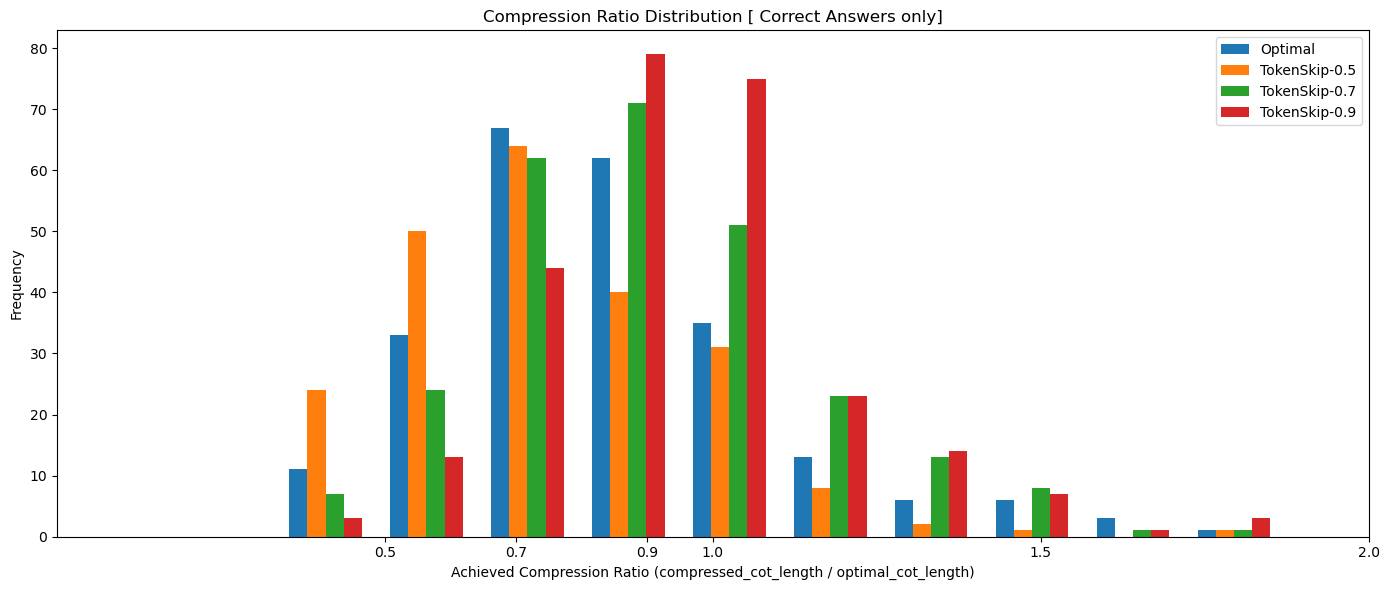

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import json

data_original = []
file_path = f"predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_original.append(json.loads(line))

data_tokenskip_05 = []
file_path = f"math-500-test/0.5/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip_05.append(json.loads(line))

tokenskip_05_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_tokenskip_05, data_original)if d1.get('accuracy') and d2.get('accuracy')]


data_tokenskip_07 = []
file_path = f"math-500-test/0.7/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip_07.append(json.loads(line))

tokenskip_07_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_tokenskip_07, data_original) if d1.get('accuracy') and d2.get('accuracy')]

data_tokenskip_09 = []
file_path = f"math-500-test/0.9/samples/max_token_1024/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_tokenskip_09.append(json.loads(line))

tokenskip_09_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_tokenskip_09, data_original) if d1.get('accuracy') and d2.get('accuracy')]

data_optimal = []
file_path = f"clustered/math-500-test/1.0/samples/predictions.jsonl"
with open(file_path, "r") as f:
    for line in f:
        data_optimal.append(json.loads(line))

optimal_cr = [d1['cot_length']/d2['cot_length'] for d1, d2 in zip(data_optimal, data_original) if d1.get('accuracy') and d2.get('accuracy')]


# compute bins
counts, bin_edges = np.histogram(tokenskip_07_cr, bins=10)

# compute counts for each method using same bins
counts_optimal, _ = np.histogram(optimal_cr, bins=bin_edges)
counts_05, _ = np.histogram(tokenskip_05_cr, bins=bin_edges)
counts_07, _ = np.histogram(tokenskip_07_cr, bins=bin_edges)
counts_09, _ = np.histogram(tokenskip_09_cr, bins=bin_edges)

# compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# bar width
width = (bin_edges[1] - bin_edges[0]) * 0.18

plt.figure(figsize=(14,6))

plt.bar(bin_centers - 1.5*width, counts_optimal, width, label="Optimal", color="#1f77b4")
plt.bar(bin_centers - 0.5*width, counts_05, width, label="TokenSkip-0.5", color="#ff7f0e")
plt.bar(bin_centers + 0.5*width, counts_07, width, label="TokenSkip-0.7", color="#2ca02c")
plt.bar(bin_centers + 1.5*width, counts_09, width, label="TokenSkip-0.9", color="#d62728")

plt.xlabel("Achieved Compression Ratio (compressed_cot_length / optimal_cot_length)")
plt.ylabel("Frequency")
plt.title("Compression Ratio Distribution [ Correct Answers only]")

# your requested x-axis ticks
plt.xticks([0.5, 0.7, 0.9, 1.0, 1.5, 2.0])

# limit axis to 2.5
plt.xlim(0, 2.0)

plt.legend()
plt.tight_layout()
plt.show()

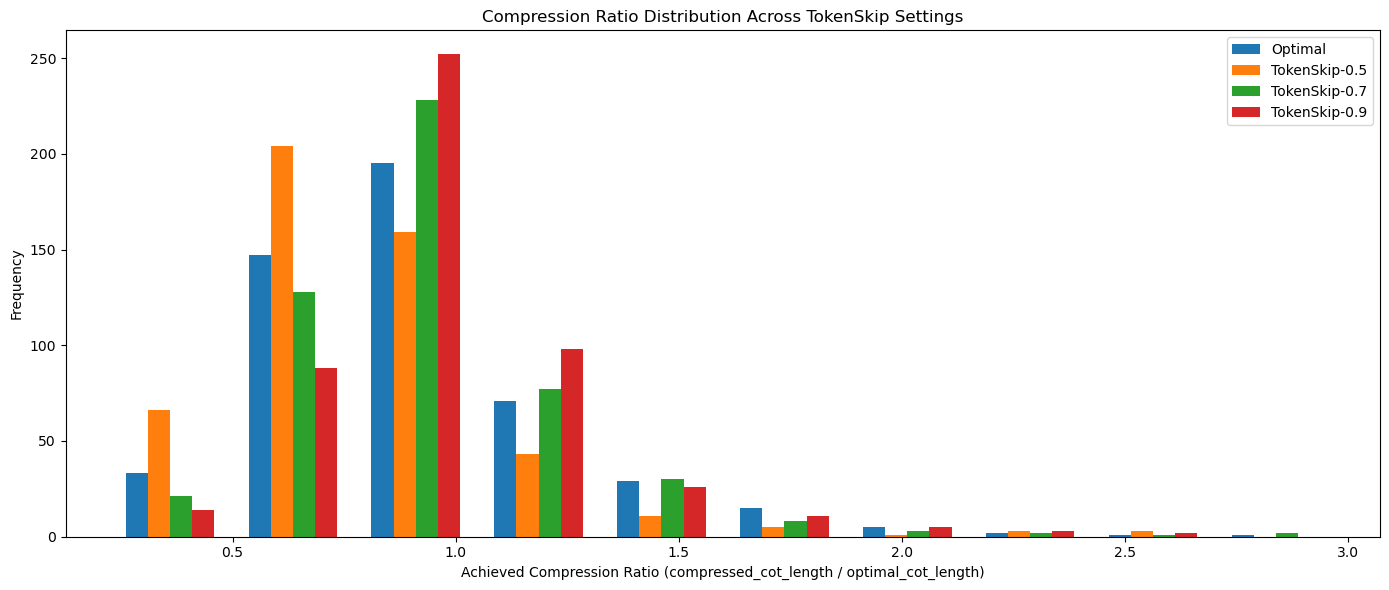

In [6]:
# compute counts for each method using same bins
counts_optimal, _ = np.histogram(optimal_cr, bins=bin_edges)
counts_05, _ = np.histogram(tokenskip_05_cr, bins=bin_edges)
counts_07, _ = np.histogram(tokenskip_07_cr, bins=bin_edges)
counts_09, _ = np.histogram(tokenskip_09_cr, bins=bin_edges)

# compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# bar width
width = (bin_edges[1] - bin_edges[0]) * 0.18

plt.figure(figsize=(14,6))

plt.bar(bin_centers - 1.5*width, counts_optimal, width, label="Optimal")
plt.bar(bin_centers - 0.5*width, counts_05, width, label="TokenSkip-0.5")
plt.bar(bin_centers + 0.5*width, counts_07, width, label="TokenSkip-0.7")
plt.bar(bin_centers + 1.5*width, counts_09, width, label="TokenSkip-0.9")

plt.xlabel("Achieved Compression Ratio (compressed_cot_length / optimal_cot_length)")
plt.ylabel("Frequency")
plt.title("Compression Ratio Distribution Across TokenSkip Settings")

plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def compute_bin_stats(data, original, bins):
    
    n_bins = len(bins) - 1
    
    correct = np.zeros(n_bins)
    incorrect = np.zeros(n_bins)
    compression_stop = np.zeros(n_bins)
    max_token_stop = np.zeros(n_bins)
    
    for d1, d2 in zip(data, original):
        
        cr = d1['cot_length'] / d2['cot_length']
        b = np.digitize(cr, bins) - 1

        if b < 0 or b >= n_bins:
            continue
        
        if d1['accuracy']:
            correct[b] += 1
        
        else:
            incorrect[b] += 1
            if d1['cot_length'] >=1023:
                max_token_stop[b] += 1
            else:
                compression_stop[b] += 1
    
    return correct, incorrect, compression_stop, max_token_stop

In [14]:
opt_correct, opt_incorrect, opt_comp, opt_max = compute_bin_stats(
    data_optimal, data_original, bin_edges)

s05_correct, s05_incorrect, s05_comp, s05_max = compute_bin_stats(
    data_tokenskip_05, data_original, bin_edges)

s07_correct, s07_incorrect, s07_comp, s07_max = compute_bin_stats(
    data_tokenskip_07, data_original, bin_edges)

s09_correct, s09_incorrect, s09_comp, s09_max = compute_bin_stats(
    data_tokenskip_09, data_original, bin_edges)

In [17]:
def plot_method_side_by_side(correct, incorrect, comp, max_tok, title):

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # width of individual bars
    width = (bin_edges[1] - bin_edges[0]) * 0.18

    plt.figure(figsize=(13,5))

    plt.bar(bin_centers - 1.5*width, correct,
            width, label="Correct", color="#2ca02c")

    plt.bar(bin_centers - 0.5*width, incorrect,
            width, label="Incorrect", color="#d62728")

    plt.bar(bin_centers + 0.5*width, comp,
            width, label="Stopped due to compression", color="#ff7f0e")

    plt.bar(bin_centers + 1.5*width, max_tok,
            width, label="Stopped due to max tokens", color="#1f77b4")

    plt.xlabel("Achieved Compression Ratio")
    plt.ylabel("Count")

    plt.xticks([0.5, 0.7, 0.9, 1.0, 1.5, 2.0])
    plt.xlim(0, 2.5)

    plt.title(title)
    plt.legend()

    plt.tight_layout()
    plt.show()

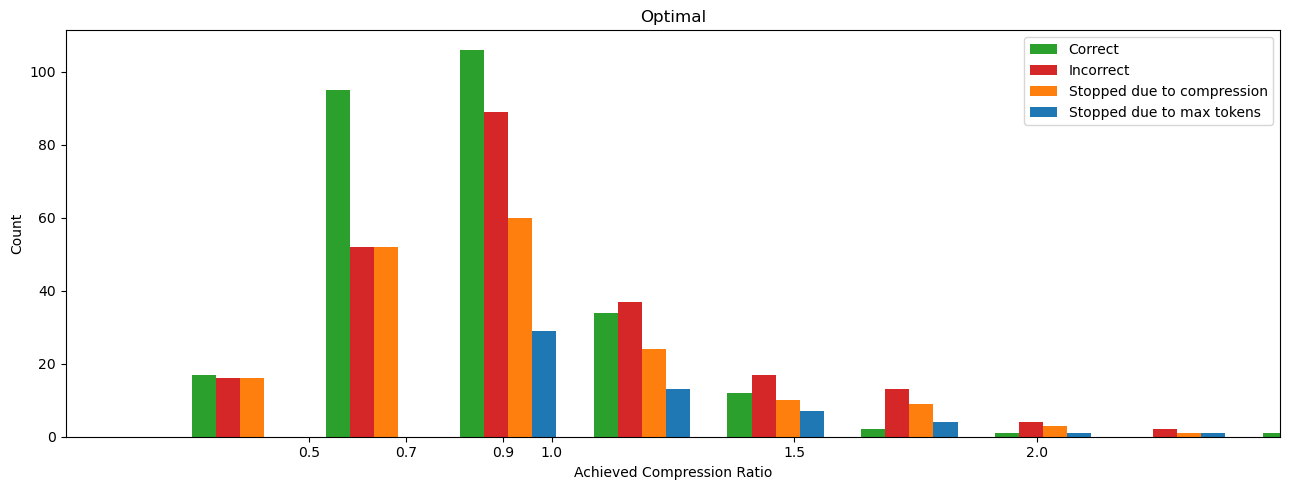

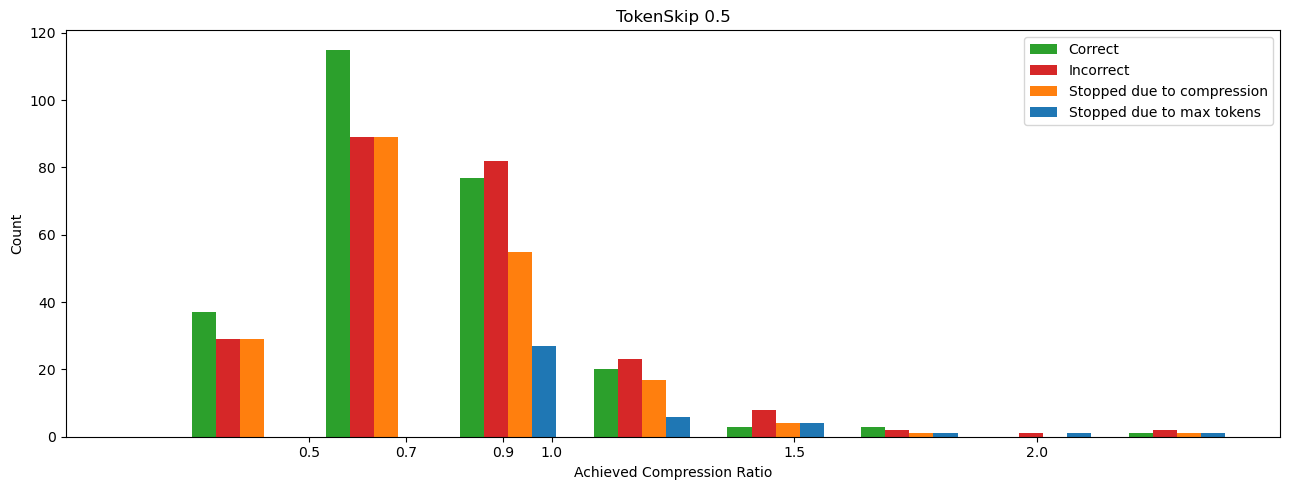

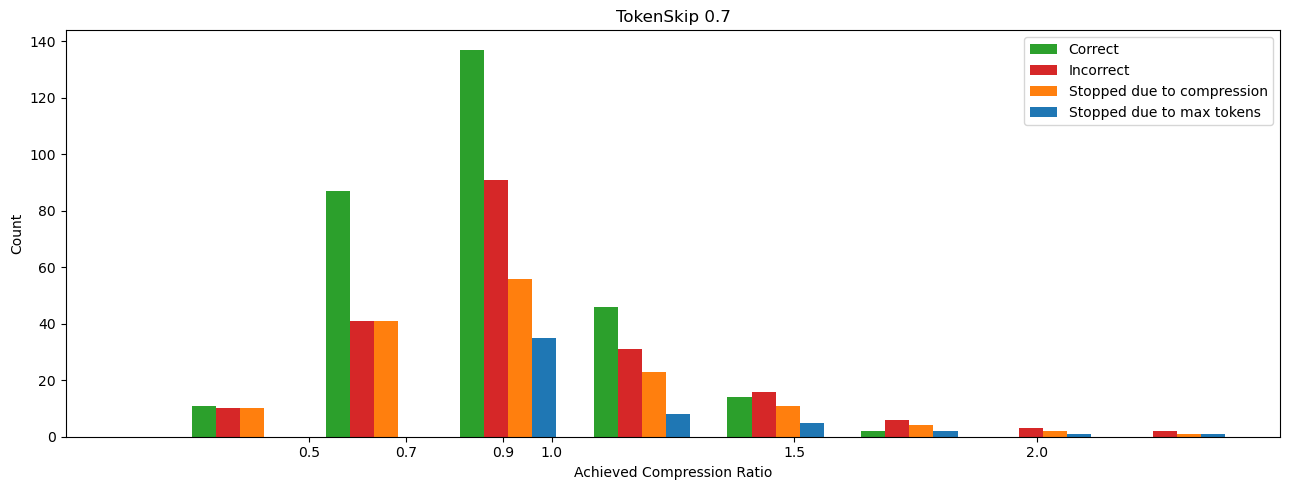

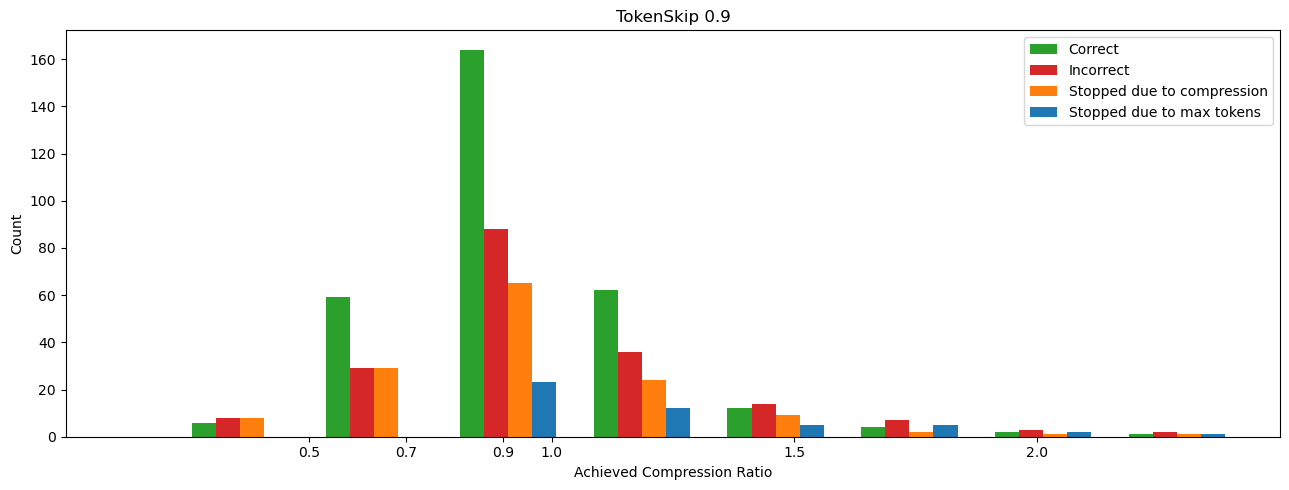

In [18]:
plot_method_side_by_side(opt_correct, opt_incorrect, opt_comp, opt_max,
                         "Optimal")

plot_method_side_by_side(s05_correct, s05_incorrect, s05_comp, s05_max,
                         "TokenSkip 0.5")

plot_method_side_by_side(s07_correct, s07_incorrect,  s07_comp, s07_max,
                         "TokenSkip 0.7")

plot_method_side_by_side(s09_correct, s09_incorrect,s09_comp, s09_max,
                         "TokenSkip 0.9")